<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/LogisRegMultiClsProblem(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression with ROC curve and ROC AUC score**

##  Mathematical Formulation of Core Concepts

### 1. Logistic Regression
Instead of predicting a hard binary label directly, Logistic Regression models the probability $P(Y=1|X)$ using the **logistic sigmoid function**. This function maps any real-valued number into a probability range between $0$ and $1$.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z$ is the linear combination of input features ($X$) and their corresponding weights ($w$), including a bias term ($b$):

$$z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b = w^TX + b$$

Therefore, the predicted probability is:
$$P(Y=1|X) = \frac{1}{1 + e^{-(w^TX + b)}}$$



### 2. Classification Threshold ($\tau$)
The model converts the continuous probability output $P(Y=1|X)$ into a discrete binary label $\hat{Y} \in \{0, 1\}$ by applying a decision threshold $\tau$ (typically set to $0.5$):

$$\hat{Y} = \begin{cases} 1 & \text{if } P(Y=1|X) \ge \tau \\ 0 & \text{if } P(Y=1|X) < \tau \end{cases}$$


### 3. Confusion Matrix Foundations
To understand the ROC curve metrics, we must first map predictions into four fundamental counts:
* **True Positives ($TP$):** Actual = 1, Predicted = 1
* **False Positives ($FP$):** Actual = 0, Predicted = 1
* **True Negatives ($TN$):** Actual = 0, Predicted = 0
* **False Negatives ($FN$):** Actual = 1, Predicted = 0


### 4. True Positive Rate (TPR / Sensitivity)
TPR measures the proportion of actual positive cases that the model correctly identifies. It answers: *Of all real positive cases, how many did we find?*

$$\text{TPR} = \frac{TP}{TP + FN}$$


### 5. False Positive Rate (FPR)
FPR measures the proportion of actual negative cases that the model incorrectly flags as positive. It answers: *Of all real negative cases, how many did we falsely alarm?*

$$\text{FPR} = \frac{FP}{FP + TN}$$

### 6. ROC Curve and ROC AUC Score
* **ROC Curve:** A parametric curve plotted by varying the threshold $\tau$ from $1$ to $0$ and computing pairs of coordinates:
$$\text{Curve}(\tau) = \Big( \text{FPR}(\tau), \, \text{TPR}(\tau) \Big)$$

* **ROC AUC Score:** Mathematically calculated as the definite integral of the True Positive Rate over the entire range of False Positive Rates:

$$\text{AUC} = \int_{0}^{1} \text{TPR}(\text{FPR}) \, d(\text{FPR})$$

* **Probabilistic Definition:** The AUC score also represents the exact probability that a randomly chosen true positive instance ($X_{pos}$) will be assigned a higher predicted probability by the model than a randomly chosen true negative instance ($X_{neg}$):
$$\text{AUC} = P\Big(P(Y=1|X_{pos}) > P(Y=1|X_{neg})\Big)$$


In [2]:
#Import basic liberies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.datasets import  make_classification


In [3]:
#Make a  dataset for x,y
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, random_state=42)

In [4]:
#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
#Create a dummy model with default 0 as output
dummy_model_pro=[0 for _ in range(len(y_test))]
dummy_model_pro

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [9]:
#Model traning
model = LogisticRegression()
model.fit(X_train, y_train)
model_prob=model.predict_proba(X_test)
model_prob=model_prob[:,1]
model_prob

array([0.01542908, 0.98986722, 0.80753802, 0.47692395, 0.09182995,
       0.36528404, 0.93826573, 0.90498171, 0.183279  , 0.87315631,
       0.96199476, 0.03007514, 0.53467659, 0.9389847 , 0.9961375 ,
       0.9505907 , 0.92503859, 0.54604837, 0.31354642, 0.1525105 ,
       0.96329917, 0.98113434, 0.9834589 , 0.68378422, 0.57572029,
       0.11724027, 0.0503064 , 0.0874203 , 0.96011524, 0.92451365,
       0.02719602, 0.9935178 , 0.28018881, 0.03987197, 0.81129126,
       0.77460148, 0.93159991, 0.98168845, 0.06909547, 0.26346294,
       0.09759828, 0.07478671, 0.08481792, 0.25374373, 0.360071  ,
       0.05511257, 0.49908641, 0.5293691 , 0.72861125, 0.01620581,
       0.92239608, 0.89736181, 0.01452652, 0.64042156, 0.13914096,
       0.20482468, 0.46683432, 0.80363864, 0.99964896, 0.64735867,
       0.9873425 , 0.02290772, 0.77564461, 0.99395178, 0.0033788 ,
       0.90843082, 0.3664881 , 0.82172474, 0.9715894 , 0.95397931,
       0.70390098, 0.76600627, 0.63823456, 0.02949186, 0.07010

In [11]:
##Lets calculate the score
dummy_score_auc=roc_auc_score(y_test,dummy_model_pro)
model_auc=roc_auc_score(y_test,model_prob)
print("Dummy Model AUC:",dummy_score_auc)
print("Model AUC:",model_auc)

Dummy Model AUC: 0.5
Model AUC: 0.9545954595459546


In [12]:
#Calculte ROC curves
dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_model_pro)
model_fpr, model_tpr, _ = roc_curve(y_test, model_prob)


In [13]:
model_fpr

array([0.        , 0.        , 0.        , 0.01980198, 0.01980198,
       0.02970297, 0.02970297, 0.03960396, 0.03960396, 0.04950495,
       0.04950495, 0.05940594, 0.05940594, 0.08910891, 0.08910891,
       0.0990099 , 0.0990099 , 0.10891089, 0.10891089, 0.11881188,
       0.11881188, 0.12871287, 0.12871287, 0.13861386, 0.13861386,
       0.14851485, 0.14851485, 0.15841584, 0.15841584, 0.16831683,
       0.16831683, 0.18811881, 0.18811881, 0.20792079, 0.20792079,
       0.27722772, 0.27722772, 0.30693069, 0.30693069, 0.6039604 ,
       0.6039604 , 1.        ])

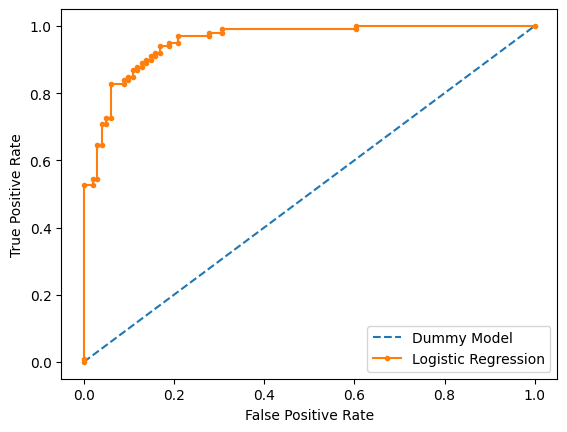

In [19]:
#Plot the roc curve for the model
plt.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
plt.plot(model_fpr, model_tpr, marker='.', label='Logistic Regression')
#Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [16]:
#Calculte ROC curves
dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_model_pro)
model_fpr, model_tpr, thresholds = roc_curve(y_test, model_prob)

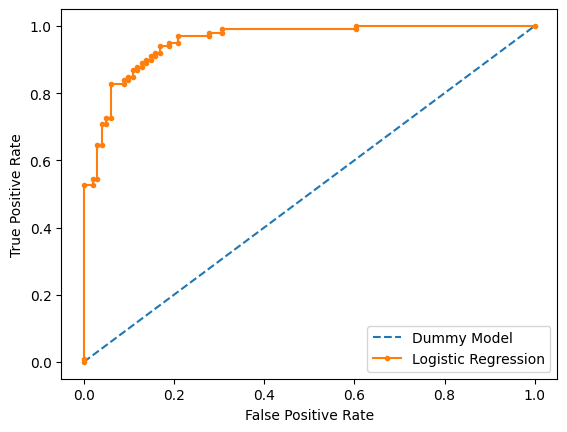

In [17]:
#Plot the curve for those
plt.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
plt.plot(model_fpr, model_tpr, marker='.', label='Logistic Regression')
#Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

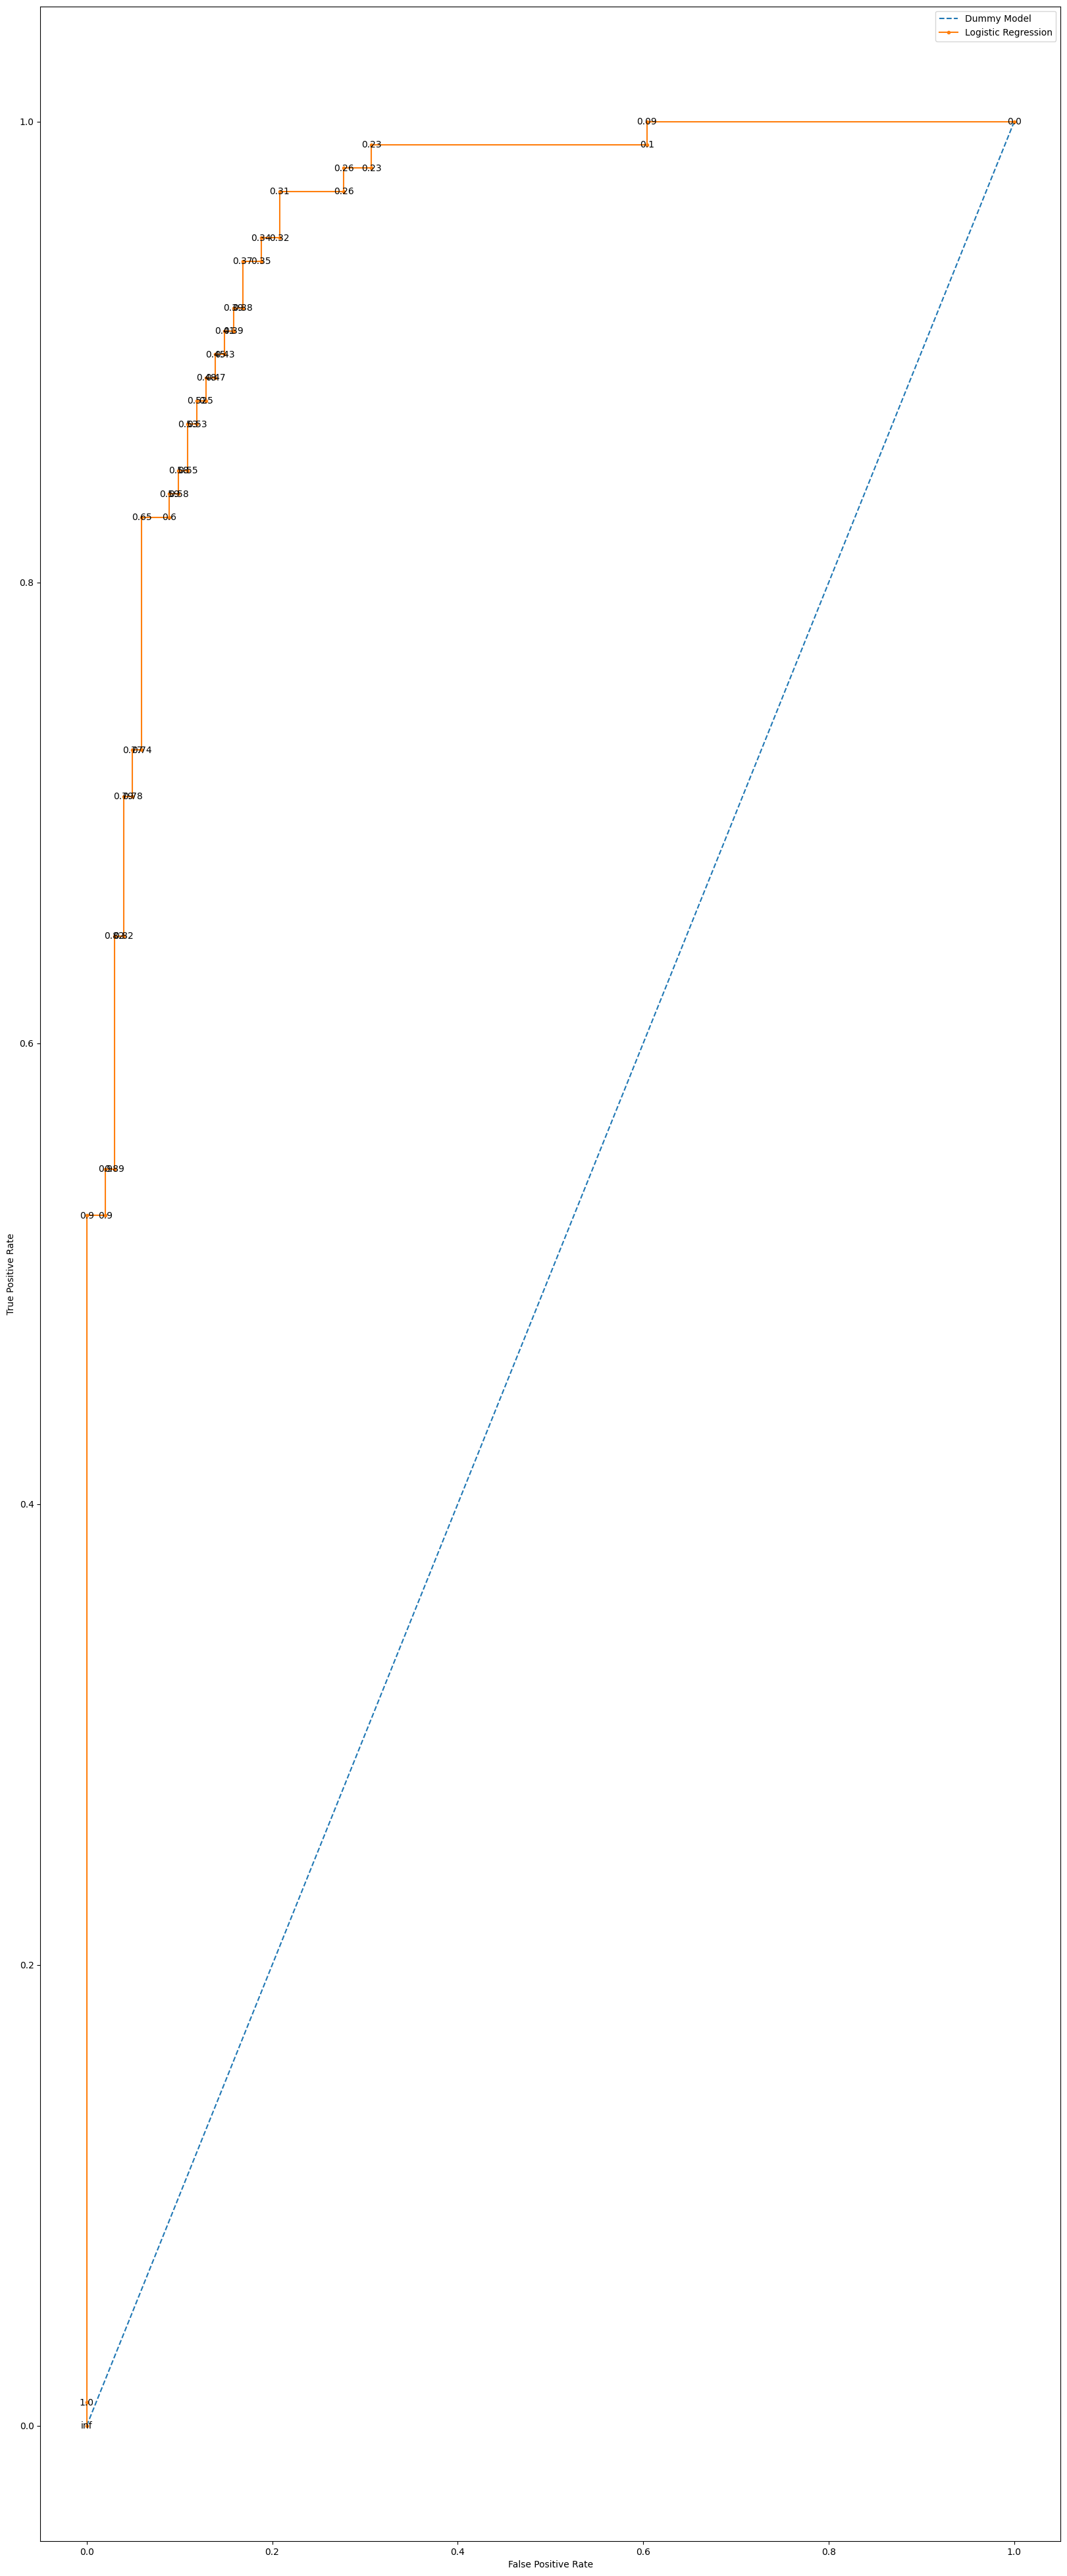

In [23]:
#Plot the roc curve for the models
fig=plt.figure(figsize=(20,50))
ax=fig.add_subplot(111)
ax.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
ax.plot(model_fpr, model_tpr, marker='.', label='Logistic Regression')
for xyz in zip(model_fpr, model_tpr,thresholds):
    ax.annotate('%s' %np.round(xyz[2],2),xy=(xyz[0], xyz[1]), ha='center', va='center')
#
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## How to Decide Which Model is Best for Your Dataset

Choosing the 'best' model for your dataset depends heavily on your specific problem, business objectives, and the nature of your data. Here are key factors and metrics to consider:

### 1. Understand Your Problem and Business Objective

*   **What are you trying to achieve?** Are you predicting customer churn, detecting fraud, categorizing images, or something else?
*   **What are the costs of different types of errors?** In fraud detection, a False Negative (missing fraud) is usually much more costly than a False Positive (false alarm). In medical diagnosis, misclassifying a sick patient as healthy (False Negative) can be severe.

### 2. Evaluate Performance Metrics

Different metrics highlight different aspects of model performance:

*   **Accuracy:** The proportion of correctly classified instances (both positive and negative) out of the total instances.
    *   **When to use:** Good for balanced datasets where both classes are equally important.
    *   **Caveat:** Can be misleading for imbalanced datasets. A model predicting the majority class all the time might have high accuracy but be useless.

*   **Precision (Positive Predictive Value):** Of all instances predicted as positive, how many were actually positive?
    *   $$\text{Precision} = \frac{TP}{TP + FP}$$
    *   **When to use:** When the cost of a False Positive is high (e.g., flagging a healthy person as sick).

*   **Recall (Sensitivity or True Positive Rate - TPR):** Of all actual positive instances, how many did the model correctly identify?
    *   $$\text{Recall} = \frac{TP}{TP + FN}$$
    *   **When to use:** When the cost of a False Negative is high (e.g., missing a fraudulent transaction).

*   **F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both metrics.
    *   $$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
    *   **When to use:** When you need a balance between Precision and Recall, especially with uneven class distribution.

*   **ROC AUC (Receiver Operating Characteristic Area Under the Curve):** As demonstrated in this notebook, AUC measures the ability of a classifier to distinguish between classes across various thresholds. A higher AUC means the model is better at separating positive and negative classes.
    *   **When to use:** A robust measure for imbalanced datasets, as it considers all possible classification thresholds. It's an overall measure of separability.

*   **PR AUC (Precision-Recall Area Under the Curve):** Similar to ROC AUC but focuses on the Precision-Recall trade-off. It's often more informative than ROC AUC for highly imbalanced datasets where the positive class is rare.
    *   **When to use:** When the positive class is of primary interest and very rare.

### 3. Consider Model Complexity and Interpretability

*   **Simpler models** (like Logistic Regression or Decision Trees) are often easier to understand and debug. They might be preferred if interpretability is crucial for regulatory reasons or stakeholder trust.
*   **Complex models** (like deep neural networks) can achieve higher performance but are often 'black boxes', making their decisions harder to explain.

### 4. Computational Cost

*   **Training time:** How long does it take to train the model, especially with large datasets?
*   **Prediction time:** How fast does the model make predictions? This is critical for real-time applications.
*   **Resource requirements:** Does the model require significant memory or processing power?

### 5. Robustness and Generalization

*   **Cross-validation:** Always use techniques like k-fold cross-validation to get a reliable estimate of your model's performance on unseen data. This helps prevent overfitting.
*   **Performance on unseen data:** The 'best' model is one that generalizes well to new, previously unseen data, not just performs well on the training data.

By carefully considering these factors and evaluating your models using appropriate metrics, you can make an informed decision about which model is truly 'best' for your specific needs.